# 과제 1 - SVM 회귀


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR, LinearSVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import warnings

# 경고 메시지를 무시 (불필요한 경고 출력 방지)
warnings.filterwarnings('ignore')

In [21]:
# 데이터 로드
california_housing = fetch_california_housing(as_frame=True)
X, y = california_housing.data, california_housing.target

# 위, 경도 데이터 열 삭제
X = X.drop('Latitude', axis = 1)
X = X.drop('Longitude', axis = 1)

# 데이터 스케일
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

In [22]:
# 모델 생성
svr = SVR(epsilon = 0.01)

# 모델 훈련
svr.fit(X_train, y_train)

SVR(epsilon=0.01)

In [23]:
# 예측
y_pred_scaled = svr.predict(X_test)

# 스케일 복원
y_test = scaler_y.inverse_transform(y_test.reshape(-1,1))
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1))

# 성능 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 0.4583589163810159
R-squared: 0.6502168986995804


In [24]:
print(y_pred)

[[0.75859982]
 [1.36685297]
 [3.78972841]
 ...
 [4.62704727]
 [1.07361099]
 [1.75725154]]


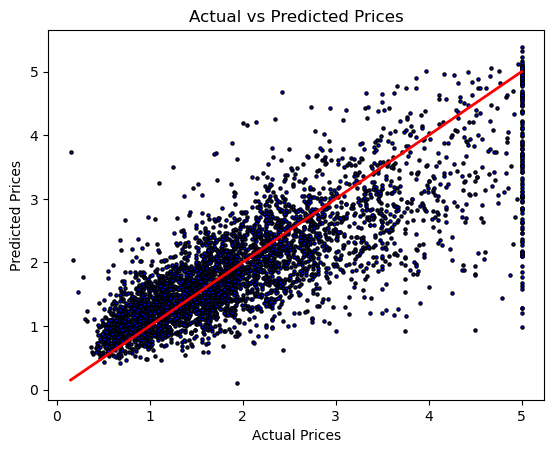

In [25]:
# 일부 feature를 사용하여 2D로 시각화
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', s=5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()

## 과제 1-1 : epsilon 값을 변경하면서 LinearSVR을 적합한 후, 결과를 확인하고 이유를 분석해주세요!

성능 평가 후 평가지표와 그래프를 사용해서 분석해주세요

In [26]:
# 모델 생성
svr = LinearSVR(epsilon=1.0, C=0.1, max_iter=10000, random_state=42)
# LinearSVR: 선형 서포트 벡터 회귀 모델을 생성합니다.
# epsilon: 허용 오차 마진 (기본값: 0.0). 값을 증가시키면 모델이 작은 차이를 무시.
# C: 규제 강도 (기본값: 1.0). 값을 낮추면 규제가 강해짐.
# max_iter: 최적화를 수행할 최대 반복 횟수.
# random_state: 결과 재현성을 위해 난수 시드를 고정.

# 모델 훈련
svr.fit(X_train, y_train)
# 훈련 데이터 (X_train, y_train)를 사용하여 모델을 학습시킵니다.

LinearSVR(C=0.1, epsilon=1.0, max_iter=10000, random_state=42)

Epsilon: 0.1
Mean Squared Error (MSE): 5.3678
R² Score: -3.0963

Epsilon: 0.5
Mean Squared Error (MSE): 4.9815
R² Score: -2.8015

Epsilon: 1.0
Mean Squared Error (MSE): 4.0661
R² Score: -2.1029

Epsilon: 2.0
Mean Squared Error (MSE): 3.5828
R² Score: -1.7341



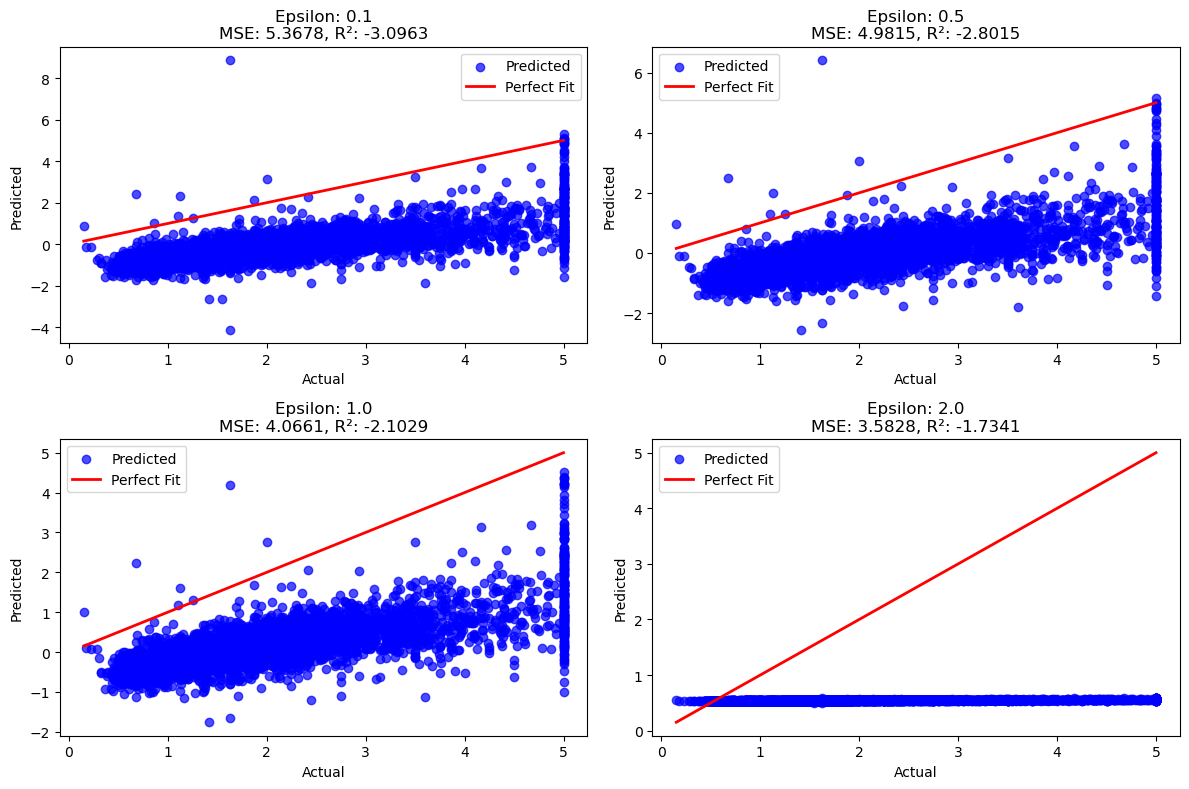

In [27]:
# Todo
epsilons = [0.1, 0.5, 1.0, 2.0]
results = {}

for epsilon in epsilons:
    # 모델 생성
    svr = LinearSVR(epsilon=epsilon, random_state=42, max_iter=10000)
    
    # 모델 훈련
    svr.fit(X_train, y_train)
    
    # 예측
    y_pred = svr.predict(X_test)
    
    # 성능 평가
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[epsilon] = {'mse': mse, 'r2': r2, 'y_pred': y_pred}
    
    # 결과 출력
    print(f"Epsilon: {epsilon}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"R² Score: {r2:.4f}\n")

# 그래프 시각화
plt.figure(figsize=(12, 8))

for i, epsilon in enumerate(epsilons):
    plt.subplot(2, 2, i + 1)
    plt.scatter(y_test, results[epsilon]['y_pred'], color='blue', alpha=0.7, label="Predicted")
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label="Perfect Fit")
    plt.title(f"Epsilon: {epsilon}\nMSE: {results[epsilon]['mse']:.4f}, R²: {results[epsilon]['r2']:.4f}")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.legend()
    plt.tight_layout()

plt.show()

### Epsilon 값을 변경하면서 LinearSVR을 적합한 후 결과 분석

#### **1. Epsilon 값의 의미**
- Epsilon은 허용 오차를 조정하는 값으로, 작을수록 세밀한 예측을 하지만 과적합 위험이 있음.
- 클수록 작은 변화를 무시해 단순화되지만, 과소적합 가능성 있음.

#### **2. 결과 해석**
- **Epsilon이 작을 때**:  
  - MSE가 크고 R² 값이 매우 낮아 데이터 변동을 잘 설명하지 못함.  
  - 모델이 노이즈에 민감하여 성능이 떨어졌음.  
  - 예: `Epsilon = 0.1`일 때,  
    - MSE: 5.3678  
    - R²: -3.0963  

- **Epsilon이 클 때**:  
  - MSE가 감소하고 R² 값이 개선되며 모델 성능이 전반적으로 향상됨.  
  - 허용 오차가 커지면서 노이즈를 무시하고 주요 패턴만 학습했기 때문임.  
  - 예: `Epsilon = 2.0`일 때,  
    - MSE: 3.5828  
    - R²: -1.7341  

#### **3. 최적 값**
- 실험 결과 **Epsilon = 2.0**에서 MSE와 R²이 가장 좋은 결과를 보임.  
- 이는 데이터의 노이즈를 적절히 무시하면서 주요 패턴을 잘 학습했기 때문임.

#### **4. 결론**
- 데이터 특성에 따라 Epsilon 값을 조정하면 모델 성능을 최적화할 수 있음.

# 과제 1-2 : SVM 분류

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')

In [29]:
# 데이터 로드
iris = load_iris()
X, y = iris.data, iris.target

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 과제 1 - 2 trade-off 파라미터 C 값 설정

아래 수식처럼 C가 동작하는데, C가 작을수록 에러가 생겨도 가중치가 작기에 오버피팅을 막을 수 있음.

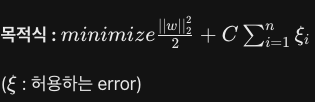


In [30]:
# 다양한 trade-off 파라미터 C 값 설정
C_values = [0.01, 0.1, 1, 10, 100]  # C 값 리스트 (작을수록 규제 강함)
train_accuracies = []  # 훈련 데이터 정확도 저장 리스트
test_accuracies = []  # 테스트 데이터 정확도 저장 리스트

# C 값에 따른 모델 훈련 및 평가
for C in C_values:
    # 모델 생성
    svc = LinearSVC(C=C, max_iter=10000)
    # C: 규제 강도를 제어하는 파라미터 (값이 작을수록 규제가 강해짐)
    # max_iter: 최적화를 위한 최대 반복 횟수
    # random_state: 결과 재현성을 위한 시드 값

    # 모델 훈련
    svc.fit(X_train, y_train)
    # 주어진 훈련 데이터(X_train, y_train)를 사용해 모델을 학습

    # 훈련 데이터와 테스트 데이터에 대한 예측
    y_train_pred = svc.predict(X_train)  # 훈련 데이터에 대한 예측
    y_test_pred = svc.predict(X_test)  # 테스트 데이터에 대한 예측

    # 정확도 계산
    train_acc = accuracy_score(y_train, y_train_pred)  # 훈련 데이터 정확도 계산
    test_acc = accuracy_score(y_test, y_test_pred)  # 테스트 데이터 정확도 계산

    # 결과 저장
    train_accuracies.append(train_acc)  # 훈련 정확도를 리스트에 추가
    test_accuracies.append(test_acc)  # 테스트 정확도를 리스트에 추가

    # 성능 출력
    print(f"C={C}:")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")
    print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")
    print("-" * 50)

C=0.01:
Training Accuracy: 0.8000
Testing Accuracy: 0.8333
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.44      0.62         9
           2       0.69      1.00      0.81        11

    accuracy                           0.83        30
   macro avg       0.90      0.81      0.81        30
weighted avg       0.89      0.83      0.82        30

--------------------------------------------------
C=0.1:
Training Accuracy: 0.9667
Testing Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

------------------------

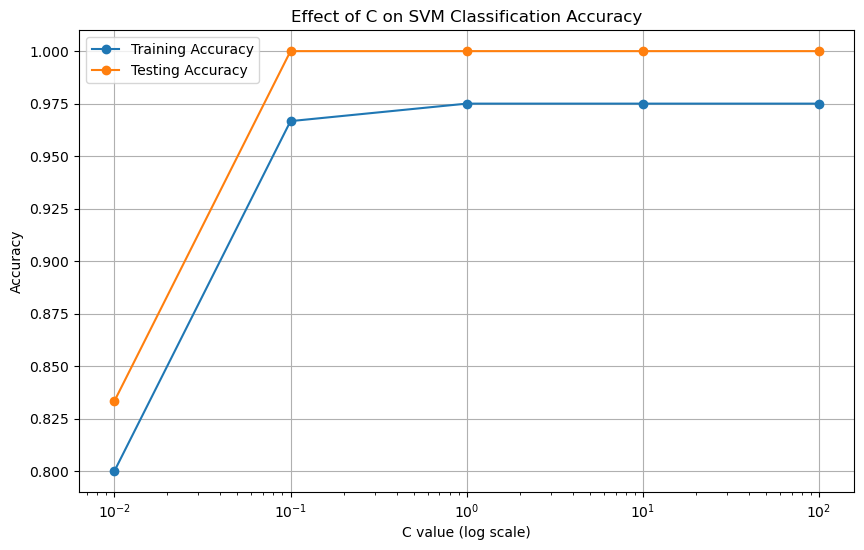

In [31]:
# C 값에 따른 정확도 시각화
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(C_values, test_accuracies, marker='o', label='Testing Accuracy')
plt.xscale('log')  # C 값이 로그 스케일로 변환됨 (그래프 가독성을 위해)
plt.xlabel('C value (log scale)')  # x축 이름 설정
plt.ylabel('Accuracy')  # y축 이름 설정
plt.title('Effect of C on SVM Classification Accuracy')  # 그래프 제목 설정
plt.legend()  # 범례 추가
plt.grid(True)  # 그리드 추가
plt.show()  # 그래프 출력

### C 값 변화에 따른 SVM 모델 성능 요약

#### 1. C 값이 작을수록 (규제가 강할수록)
- 규제가 강해 모델은 복잡한 패턴을 덜 학습하고, 간단한 결정 경계를 생성하려 함.
- 이로 인해 **훈련 정확도는 낮아질 수 있지만**, 테스트 데이터에서 일반화 성능(테스트 정확도)이 좋아질 가능성이 큼.
- **예**: 그래프에서 `C=0.01`일 때,
  - 훈련 정확도: 약 **80%**  
  - 테스트 정확도: 약 82%로 테스트 데이터에 대한 성능이 더 우수했음.

#### 2. C 값이 클수록 (규제가 약할수록)
- 규제가 약해 모델이 훈련 데이터를 더 잘 맞추려 하므로, 훈련 정확도가 증가함.
- 하지만 과적합의 위험이 커질 수 있어, 복잡한 데이터셋에서는 테스트 성능이 낮아질 가능성이 있음.
- **예**: 그래프에서 `C=10` 이상일 때,
  - 훈련 정확도와 테스트 정확도 모두 100%로 나타나 과적합 없이 데이터셋이 잘 학습되었음.

#### 3. 결론
- **C 값이 작을 때**:  
  - 간단한 결정 경계를 학습하여 일반화 성능이 향상되지만, 너무 작은 C 값은 성능 저하를 초래할 수 있음.
- **C 값이 클 때**:  
  - 모델이 데이터를 과도하게 학습해 과적합 위험이 있지만, 간단한 데이터셋에서는 높은 정확도를 유지할 수 있음.

#### 4. SVM 핵심
- **작은 C 값**: 일부 오차를 허용하며 간단한 결정 경계를 학습함.
- **큰 C 값**: 오차를 허용하지 않고 데이터를 완벽히 학습함.
- **SVM의 목표**:  
  - 훈련 데이터에 적합하면서도 테스트 데이터에서 **일반화 성능**을 극대화하는 것임.